We are going to map a contamination site and make a watershed simulation map to demonstright GIS abilites. 

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point, LineString

In [ ]:
# Load Saskatchewan boundary (same as Day 1)
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/canada.geojson"
gdf = gpd.read_file(url)
sk = gdf[gdf["name"] == "Saskatchewan"].copy()

# Load the sampling sites you saved yesterday
sites = gpd.read_file("data/sampling_sites.gpkg")

# Always check CRS match first — (this is the #1 source of bugs in GIS)
print("SK CRS:   ", sk.crs)
print("Sites CRS:", sites.crs)
print("Match?    ", sk.crs == sites.crs)

SK CRS:    EPSG:4326
Sites CRS: EPSG:4326
Match?     True


In [4]:
# Reproject both layers to Canada Lambert — metres as units
sk_proj = sk.to_crs(epsg=3347)
sites_proj = sites.to_crs(epsg=3347)

print("Units are now:", sk_proj.crs.axis_info[0].unit_name)
print("Sample site geometry:", sites_proj.geometry.iloc[0])

Units are now: metre
Sample site geometry: POINT (5289512.162824164 2073764.587930327)


Original geometry type: ['Point']
Buffered geometry type: ['Polygon']

Buffer area (first site): 7841.4 km²
Expected (π × 50²):       7854.0 km²


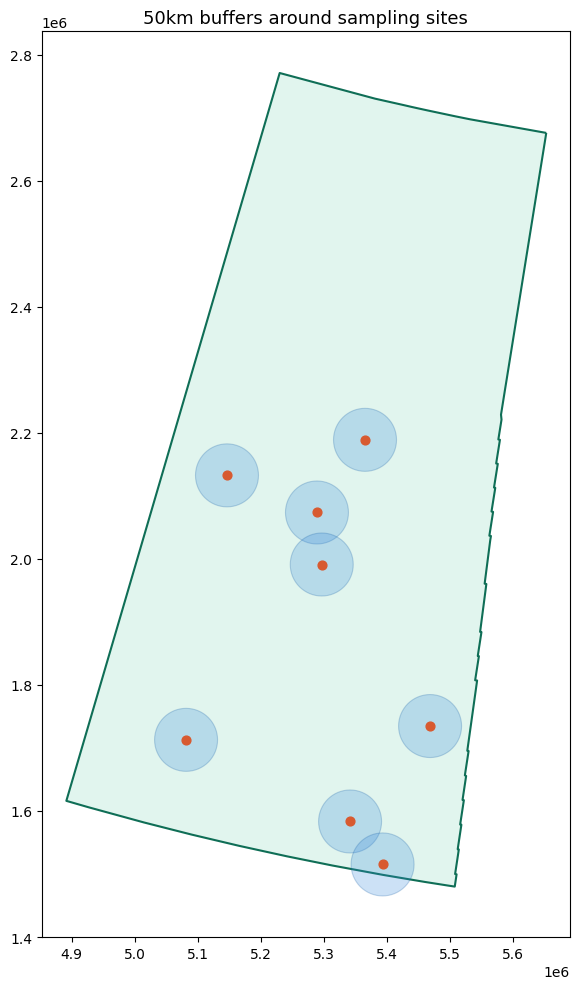

In [5]:
# Create 50km buffers around each sampling site
# Units are metres because we're in EPSG:3347
buffer_distance_m = 50_000  # 50km

sites_buffered = sites_proj.copy()
sites_buffered["geometry"] = sites_proj.geometry.buffer(buffer_distance_m)

print("Original geometry type:", sites_proj.geometry.geom_type.unique())
print("Buffered geometry type:", sites_buffered.geometry.geom_type.unique())
print(f"\nBuffer area (first site): {sites_buffered.geometry.area.iloc[0] / 1_000_000:.1f} km²")
print(f"Expected (π × 50²):       {3.14159 * 50**2:.1f} km²")  # sanity check

# Plot to see what buffers look like
fig, ax = plt.subplots(figsize=(8, 10))
sk_proj.plot(ax=ax, color="#E1F5EE", edgecolor="#0F6E56", linewidth=1.5)
sites_buffered.plot(ax=ax, color="#378ADD", alpha=0.25, edgecolor="#185FA5", linewidth=0.8)
sites_proj.plot(ax=ax, color="#D85A30", markersize=40, zorder=5)
ax.set_title("50km buffers around sampling sites", fontsize=13)
plt.tight_layout()
plt.savefig("day2_buffers.png", dpi=150, bbox_inches="tight")
plt.show()

I have a 50km buffer zone around the sampling sites. I can see overlap between some of the sites. I am now going to study a single site and map contamination zones aroun it. I wil do Weyburn.

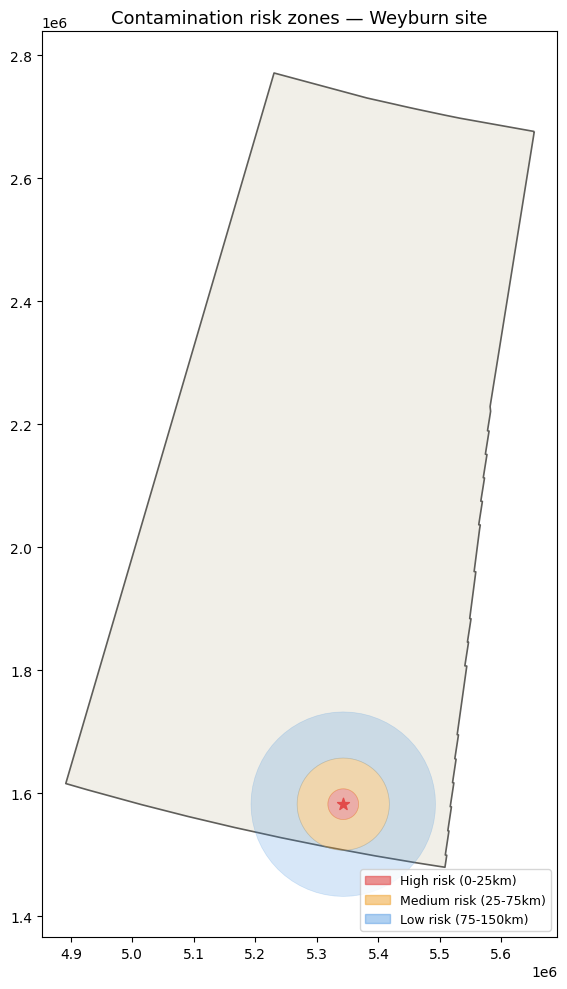

Key method used: .difference() — subtracts one geometry from another
This is called a 'donut buffer' or 'annular buffer' in GIS


In [6]:
# Simulate a single contamination source — Weyburn, SK
source = sites_proj[sites_proj["name"] == "Weyburn"].copy()

# Create three concentric risk zones
zones = {
    "High risk (0-25km)":   (0,      25_000, "#E24B4A", 0.4),
    "Medium risk (25-75km)":(25_000, 75_000, "#EF9F27", 0.3),
    "Low risk (75-150km)":  (75_000, 150_000,"#378ADD", 0.2),
}

fig, ax = plt.subplots(figsize=(8, 10))
sk_proj.plot(ax=ax, color="#F1EFE8", edgecolor="#5F5E5A", linewidth=1.2)

patches = []
for label, (inner, outer, color, alpha) in zones.items():
    outer_buf = source.geometry.buffer(outer).values[0]
    inner_buf = source.geometry.buffer(inner).values[0]
    donut = outer_buf.difference(inner_buf)   # subtract inner from outer = ring shape
    
    gpd.GeoSeries([donut], crs=sk_proj.crs).plot(
        ax=ax, color=color, alpha=alpha, edgecolor=color, linewidth=0.5
    )
    patches.append(mpatches.Patch(color=color, alpha=alpha+0.2, label=label))

source.plot(ax=ax, color="#E24B4A", markersize=80, zorder=5, marker="*")
ax.legend(handles=patches, loc="lower right", fontsize=9)
ax.set_title("Contamination risk zones — Weyburn site", fontsize=13)
plt.tight_layout()
plt.savefig("day2_risk_zones.png", dpi=150, bbox_inches="tight")
plt.show()

print("Key method used: .difference() — subtracts one geometry from another")
print("This is called a 'donut buffer' or 'annular buffer' in GIS")

I want to simulate mapping waterhsed zones as flow of water is important for understanding where contaminates will flow, This is a rough simualtion.

SK bounding box (metres):
  X: 4,890,953 to 5,652,615
  Y: 1,480,809 to 2,772,050

Watersheds created:
  watershed_id watershed_name
0        WS-01    North Basin
1        WS-02  Central North
2        WS-03       NE Basin
3        WS-04   West Central
4        WS-05     Qu'Appelle
5        WS-06   East Central
6        WS-07      Southwest
7        WS-08  South Central
8        WS-09      Southeast


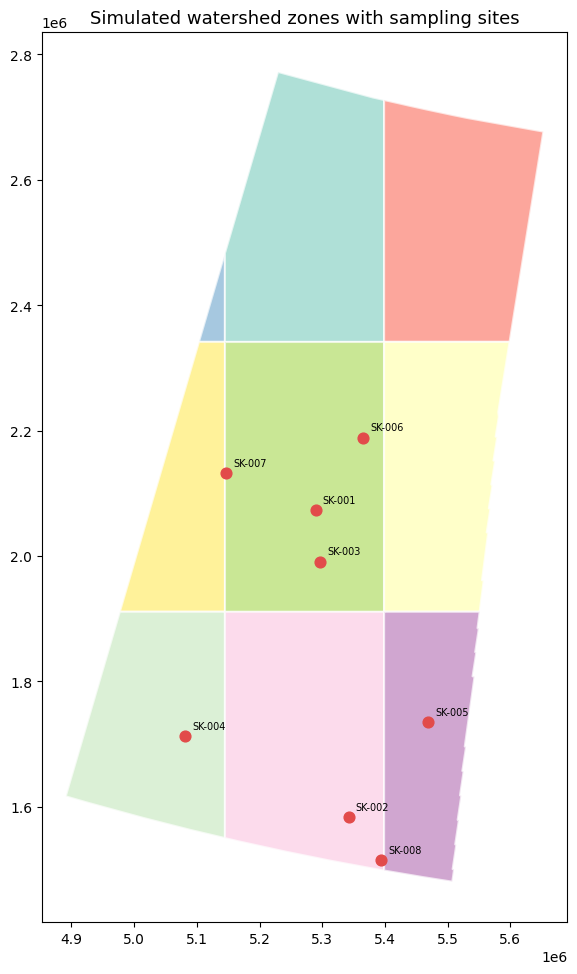

In [7]:
from shapely.geometry import box
import numpy as np

# Get Saskatchewan's bounding box in projected coordinates
minx, miny, maxx, maxy = sk_proj.total_bounds
print(f"SK bounding box (metres):\n  X: {minx:,.0f} to {maxx:,.0f}\n  Y: {miny:,.0f} to {maxy:,.0f}")

# Divide into a 3x3 grid of simulated watershed zones
cols = 3
rows = 3
cell_w = (maxx - minx) / cols
cell_h = (maxy - miny) / rows

watershed_names = [
    "North Basin",   "Central North", "NE Basin",
    "West Central",  "Qu'Appelle",    "East Central",
    "Southwest",     "South Central", "Southeast"
]

watersheds = []
for row in range(rows):
    for col in range(cols):
        x0 = minx + col * cell_w
        y0 = miny + (rows - 1 - row) * cell_h   # flip so row 0 = top
        cell = box(x0, y0, x0 + cell_w, y0 + cell_h)
        # clip to SK boundary so we don't have zones outside the province
        clipped = cell.intersection(sk_proj.geometry.union_all())
        watersheds.append({
            "watershed_id": f"WS-{row*cols + col + 1:02d}",
            "watershed_name": watershed_names[row * cols + col],
            "geometry": clipped
        })

watersheds_gdf = gpd.GeoDataFrame(watersheds, crs=sk_proj.crs)

# Preview
print("\nWatersheds created:")
print(watersheds_gdf[["watershed_id", "watershed_name"]])

# Plot zones
fig, ax = plt.subplots(figsize=(8, 10))
watersheds_gdf.plot(ax=ax, column="watershed_name", cmap="Set3",
                    edgecolor="white", linewidth=1.5, alpha=0.7)
sites_proj.plot(ax=ax, color="#E24B4A", markersize=60, zorder=5)

for _, row in sites_proj.iterrows():
    ax.annotate(row["site_id"], xy=(row.geometry.x, row.geometry.y),
                xytext=(5, 5), textcoords="offset points", fontsize=7)

ax.set_title("Simulated watershed zones with sampling sites", fontsize=13)
plt.tight_layout()
plt.savefig("day2_watersheds.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# sjoin = spatial join
# how="left"  means keep all sites even if they don't match a watershed
# predicate="within" means "site point must be inside the watershed polygon"

sites_joined = gpd.sjoin(
    sites_proj,
    watersheds_gdf[["watershed_id", "watershed_name", "geometry"]],
    how="left",
    predicate="within"
)

print("Columns after spatial join:")
print(sites_joined.columns.tolist())
print("\nEach site now knows which watershed it belongs to:")
print(sites_joined[["site_id", "name", "parameter", "value", "watershed_name"]].to_string())

# How many sites per watershed?
print("\nSites per watershed:")
print(sites_joined.groupby("watershed_name")["site_id"].count().sort_values(ascending=False))

Columns after spatial join:
['site_id', 'name', 'parameter', 'value', 'longitude', 'latitude', 'in_sk', 'geometry', 'index_right', 'watershed_id', 'watershed_name']

Each site now knows which watershed it belongs to:
  site_id           name     parameter  value watershed_name
0  SK-001       Waskesiu            pH    7.2     Qu'Appelle
1  SK-002        Weyburn            pH    6.8  South Central
2  SK-003  Prince Albert  conductivity  450.0     Qu'Appelle
3  SK-004  Swift Current  conductivity  380.0      Southwest
4  SK-005        Yorkton            pH    7.5      Southeast
5  SK-006       La Ronge  conductivity  290.0     Qu'Appelle
6  SK-007    Meadow Lake            pH    6.9     Qu'Appelle
7  SK-008        Estevan  conductivity  510.0  South Central

Sites per watershed:
watershed_name
Qu'Appelle       4
South Central    2
Southeast        1
Southwest        1
Name: site_id, dtype: int64


Watershed summary table:
watershed_name  site_count  mean_value  max_value       parameters
    Qu'Appelle           4     188.525      450.0 pH, conductivity
 South Central           2     258.400      510.0 pH, conductivity
     Southeast           1       7.500        7.5               pH
     Southwest           1     380.000      380.0     conductivity


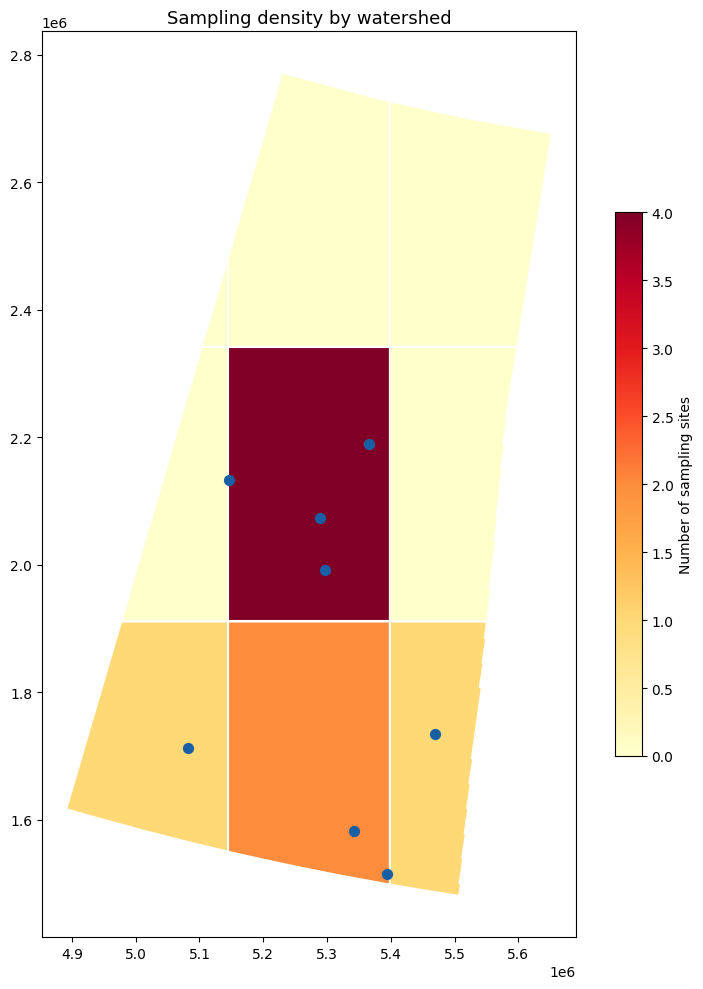

In [9]:
# Calculate stats per watershed
watershed_summary = sites_joined.groupby("watershed_name").agg(
    site_count   = ("site_id", "count"),
    mean_value   = ("value",   "mean"),
    max_value    = ("value",   "max"),
    parameters   = ("parameter", lambda x: ", ".join(x.unique()))
).reset_index()

print("Watershed summary table:")
print(watershed_summary.to_string(index=False))

# Merge summary back onto the watershed geometries for mapping
watersheds_summary = watersheds_gdf.merge(
    watershed_summary, on="watershed_name", how="left"
)
watersheds_summary["site_count"] = watersheds_summary["site_count"].fillna(0)

# Choropleth map — colour by number of sites
fig, ax = plt.subplots(figsize=(8, 10))
watersheds_summary.plot(
    ax=ax, column="site_count", cmap="YlOrRd",
    edgecolor="white", linewidth=1.5,
    legend=True,
    legend_kwds={"label": "Number of sampling sites", "shrink": 0.6}
)
sites_proj.plot(ax=ax, color="#185FA5", markersize=50, zorder=5)
ax.set_title("Sampling density by watershed", fontsize=13)
plt.tight_layout()
plt.savefig("day2_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

Qu'Appelle is the watershed with the most points meaning it has the highest risk of moving contamination.

I want to simulate study area aroudn Qu'Appelle 

Sites before clip: 8
Sites after clip:  4

Sites inside study area:
  site_id           name
2  SK-003  Prince Albert
0  SK-001       Waskesiu
6  SK-007    Meadow Lake
5  SK-006       La Ronge


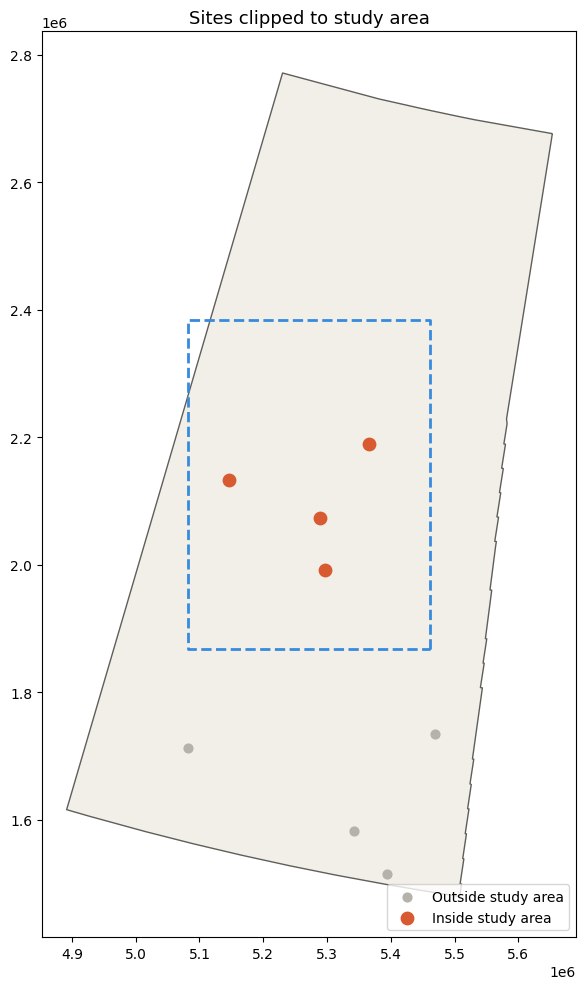

In [10]:
# Simulate a study area — a rectangle in central Saskatchewan
from shapely.geometry import box

study_area = gpd.GeoDataFrame(
    {"name": ["Central SK Study Area"]},
    geometry=[box(
        sk_proj.total_bounds[0] + (sk_proj.total_bounds[2] - sk_proj.total_bounds[0]) * 0.25,
        sk_proj.total_bounds[1] + (sk_proj.total_bounds[3] - sk_proj.total_bounds[1]) * 0.30,
        sk_proj.total_bounds[0] + (sk_proj.total_bounds[2] - sk_proj.total_bounds[0]) * 0.75,
        sk_proj.total_bounds[1] + (sk_proj.total_bounds[3] - sk_proj.total_bounds[1]) * 0.70,
    )],
    crs=sk_proj.crs
)

# Clip sites to study area — only keep sites inside the box
sites_clipped = gpd.clip(sites_proj, study_area)

print(f"Sites before clip: {len(sites_proj)}")
print(f"Sites after clip:  {len(sites_clipped)}")
print("\nSites inside study area:")
print(sites_clipped[["site_id", "name"]])

fig, ax = plt.subplots(figsize=(8, 10))
sk_proj.plot(ax=ax, color="#F1EFE8", edgecolor="#5F5E5A", linewidth=1)
study_area.plot(ax=ax, color="none", edgecolor="#378ADD", linewidth=2, linestyle="--")
sites_proj.plot(ax=ax, color="#B4B2A9", markersize=40, label="Outside study area")
sites_clipped.plot(ax=ax, color="#D85A30", markersize=80, zorder=5, label="Inside study area")
ax.legend(loc="lower right")
ax.set_title("Sites clipped to study area", fontsize=13)
plt.tight_layout()
plt.savefig("day2_clip.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Distance from every site to every other site
print("Distance matrix (km) between sites:\n")

site_names = sites_proj["name"].tolist()
n = len(sites_proj)

# Build a readable distance matrix
rows = []
for i, row_i in sites_proj.iterrows():
    dist_row = {}
    for j, row_j in sites_proj.iterrows():
        dist_km = row_i.geometry.distance(row_j.geometry) / 1000
        dist_row[row_j["name"]] = round(dist_km, 1)
    rows.append(dist_row)

dist_df = pd.DataFrame(rows, index=site_names)
print(dist_df.to_string())

# Find the two closest sites
min_dist = float("inf")
closest_pair = ("", "")
for i, row_i in sites_proj.iterrows():
    for j, row_j in sites_proj.iterrows():
        if i >= j:
            continue
        d = row_i.geometry.distance(row_j.geometry) / 1000
        if d < min_dist:
            min_dist = d
            closest_pair = (row_i["name"], row_j["name"])

print(f"\nClosest pair of sites: {closest_pair[0]} ↔ {closest_pair[1]}")
print(f"Distance: {min_dist:.1f} km")

Distance matrix (km) between sites:

               Waskesiu  Weyburn  Prince Albert  Swift Current  Yorkton  La Ronge  Meadow Lake  Estevan
Waskesiu            0.0    493.2           82.9          416.4    383.6     138.2        154.5    568.2
Weyburn           493.2      0.0          410.3          290.8    197.6     606.2        583.0     85.5
Prince Albert      82.9    410.3            0.0          351.9    308.7     209.4        206.5    485.7
Swift Current     416.4    290.8          351.9            0.0    387.9     554.4        424.8    369.3
Yorkton           383.6    197.6          308.7          387.9      0.0     465.8        512.0    232.2
La Ronge          138.2    606.2          209.4          554.4    465.8       0.0        226.2    674.5
Meadow Lake       154.5    583.0          206.5          424.8    512.0     226.2          0.0    665.1
Estevan           568.2     85.5          485.7          369.3    232.2     674.5        665.1      0.0

Closest pair of sites: Was

In [ ]:
# Save all the outputs into one GeoPackage
# GeoPackage supports multiple layers in one file — like an Excel workbook with multiple sheets

output_path = "data/day2_outputs.gpkg"

sites_proj.to_file(output_path, layer="sampling_sites",   driver="GPKG")
watersheds_gdf.to_file(output_path, layer="watersheds",   driver="GPKG")
sites_joined.to_file(output_path, layer="sites_with_watershed", driver="GPKG")
study_area.to_file(output_path, layer="study_area",       driver="GPKG")

print("Saved layers to", output_path)
print("\nLayers in file:")
import fiona
for layer in fiona.listlayers(output_path):
    print(" -", layer)